<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana4/ParabolicoFriccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

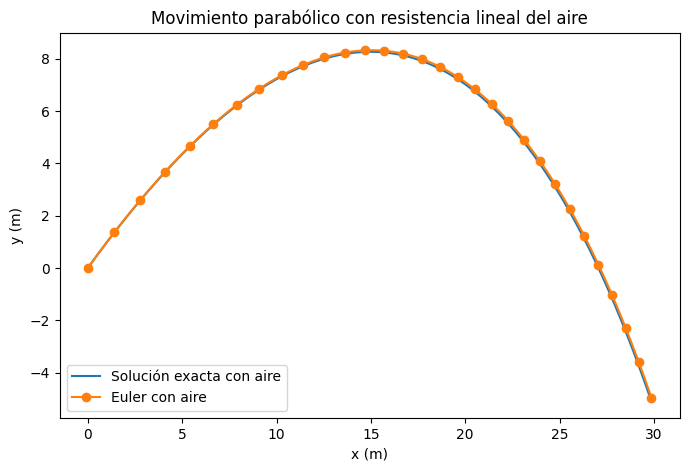

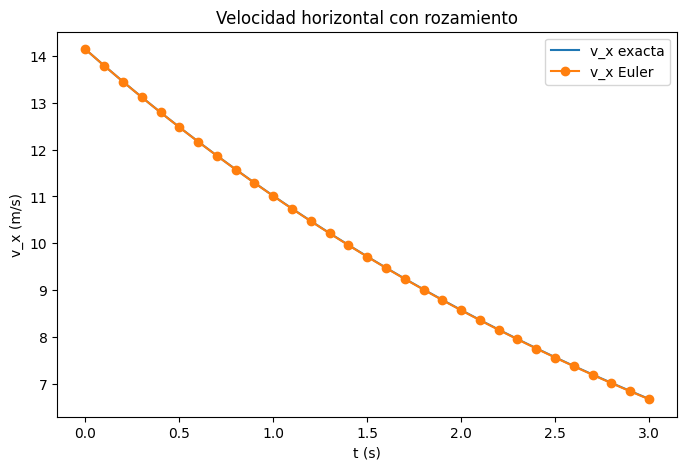

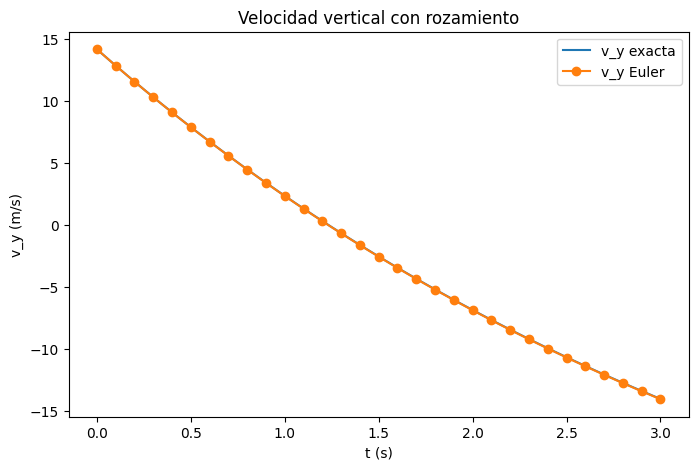

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# -----------------------------
# Parámetros físicos
# -----------------------------
g = 9.81
v0 = 20.0
theta = np.deg2rad(45)
x0, y0 = 0.0, 0.0

vx0 = v0 * np.cos(theta)
vy0 = v0 * np.sin(theta)

# Parámetro de fricción lineal
k = 0.25   # s^{-1}

# Tiempo de simulación
t_total = 3.0
dt = 0.01
N = int(t_total / dt) + 1

# -----------------------------
# Arreglos para Euler
# -----------------------------
t_euler = np.zeros(N)
x_euler = np.zeros(N)
y_euler = np.zeros(N)
vx_euler = np.zeros(N)
vy_euler = np.zeros(N)

# Condiciones iniciales
x_euler[0], y_euler[0] = x0, y0
vx_euler[0], vy_euler[0] = vx0, vy0

# -----------------------------
# Método de Euler
# -----------------------------
for n in range(N - 1):
    t_euler[n+1] = t_euler[n] + dt

    x_euler[n+1] = x_euler[n] + dt * vx_euler[n]
    y_euler[n+1] = y_euler[n] + dt * vy_euler[n]

    vx_euler[n+1] = vx_euler[n] + dt * (-k * vx_euler[n])
    vy_euler[n+1] = vy_euler[n] + dt * (-k * vy_euler[n] - g)

# -----------------------------
# Solución exacta
# -----------------------------
t_exact = np.linspace(0, t_total, 1000)

vx_exact = vx0 * np.exp(-k * t_exact)
vy_exact = (vy0 + g/k) * np.exp(-k * t_exact) - g/k

x_exact = x0 + (vx0 / k) * (1 - np.exp(-k * t_exact))
y_exact = y0 + (1/k) * (vy0 + g/k) * (1 - np.exp(-k * t_exact)) - (g/k) * t_exact

# -----------------------------
# Graficar trayectoria
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(x_exact, y_exact, label='Solución exacta con aire')
plt.plot(x_euler, y_euler, 'o-', markevery=10, label='Euler con aire')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Movimiento parabólico con resistencia lineal del aire')
plt.legend()
plt.savefig("Trayectoria_aire.pdf",dpi=300)
plt.show()

# -----------------------------
# Graficar velocidad horizontal
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(t_exact, vx_exact, label='v_x exacta')
plt.plot(t_euler, vx_euler, 'o-', markevery=10, label='v_x Euler')
plt.xlabel('t (s)')
plt.ylabel('v_x (m/s)')
plt.title('Velocidad horizontal con rozamiento')
plt.legend()
plt.savefig("Velocidad_horizontal_aire.pdf",dpi=300)
plt.show()

# -----------------------------
# Graficar velocidad vertical
# -----------------------------
plt.figure(figsize=(8,5))
plt.plot(t_exact, vy_exact, label='v_y exacta')
plt.plot(t_euler, vy_euler, 'o-', markevery=10, label='v_y Euler')
plt.xlabel('t (s)')
plt.ylabel('v_y (m/s)')
plt.title('Velocidad vertical con rozamiento')
plt.legend()
plt.savefig("Velocidad_vertical_aire.pdf",dpi=300)
plt.show()

# -----------------------------
# Descargar archivos
# -----------------------------
files.download("Trayectoria_aire.pdf")
files.download("Velocidad_horizontal_aire.pdf")
files.download("Velocidad_vertical_aire.pdf")